In [1]:
import pandas as pd
import torch
import torch.nn as nn

import model_definitions
import training
import data_preprocessing
import visualization
import arima_forecasting

Loading the data and getting familiar with it.

In [2]:
data_path = 'data/IBM_2006-01-01_to_2018-01-01.csv'

df = data_preprocessing.load_and_clean_data(data_path)

df.describe()

Missing values in each column:
Date      0
Open      1
High      0
Low       1
Close     0
Volume    0
Name      0
dtype: int64


c:\Users\eknut\Documents\Koodit\Projektit\stock-market-forecasting\data_preprocessing.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,Open,High,Low,Close,Volume
count,3020.000000,3020.000000,3020.000000,3020.000000,3.020000e+03
mean,145.515311,146.681738,144.471387,145.617278,5.773301e+06
std,37.548728,37.613446,37.471435,37.529387,3.192831e+06
min,72.740000,73.940000,69.500000,71.740000,2.542560e+05
25%,116.407500,117.765000,115.500000,116.525000,3.622681e+06
50%,149.605000,150.330000,148.425000,149.315000,4.928852e+06
75%,178.437500,179.762500,177.320000,178.685000,6.965014e+06
max,215.380000,215.900000,214.300000,215.800000,3.077428e+07


Data preprocessing

In [3]:
series = df["Open"]

train, test = data_preprocessing.split_series(series)

Extracting trend, seasonality and residuals from the time series data.

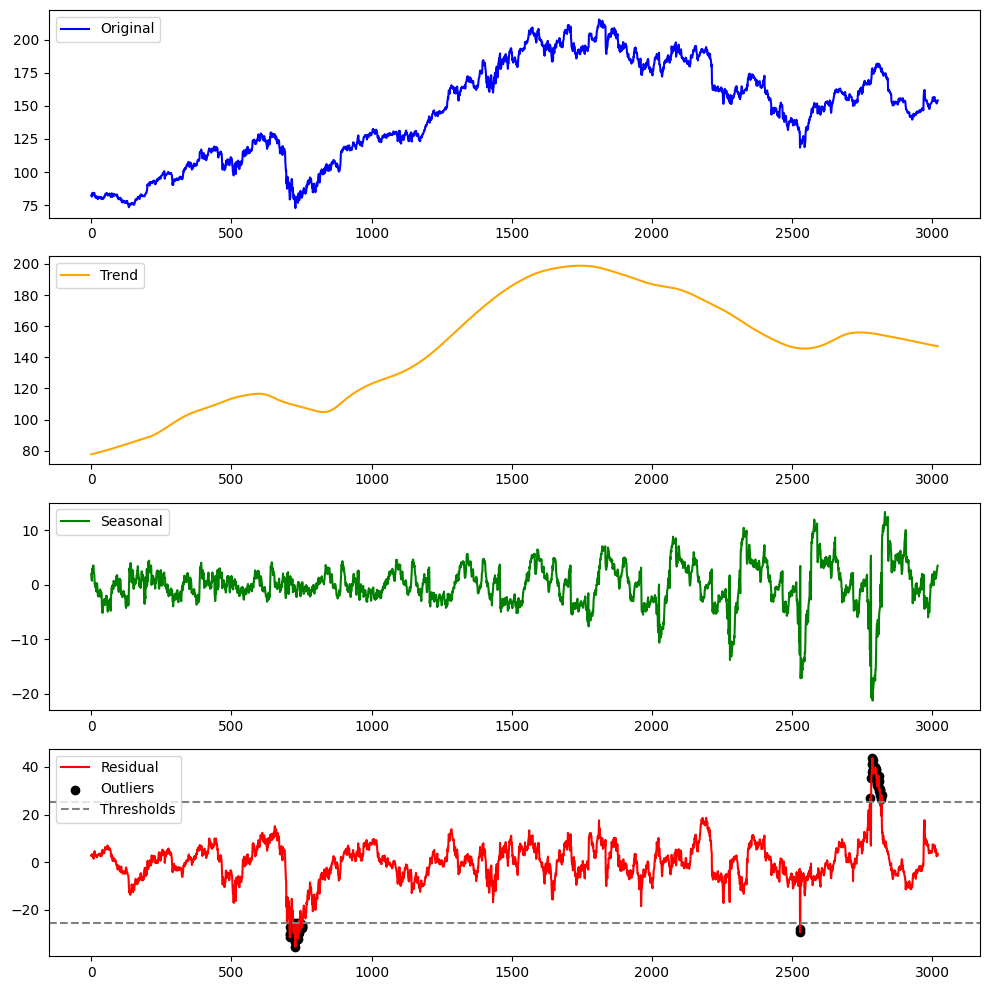

Number of outliers found: 68
Threshold: +/- 25.3331


In [4]:
indexes = pd.RangeIndex(start=0, stop=len(df), step=1)

res = data_preprocessing.stl_decompose(series, period=252, seasonal=13)

trend = res.trend
seasonal = res.seasonal
resid = res.resid

visualization.plot_stl_decomposition(indexes, series, trend, seasonal, resid)

Plotting raw data for opening prices and volumes.

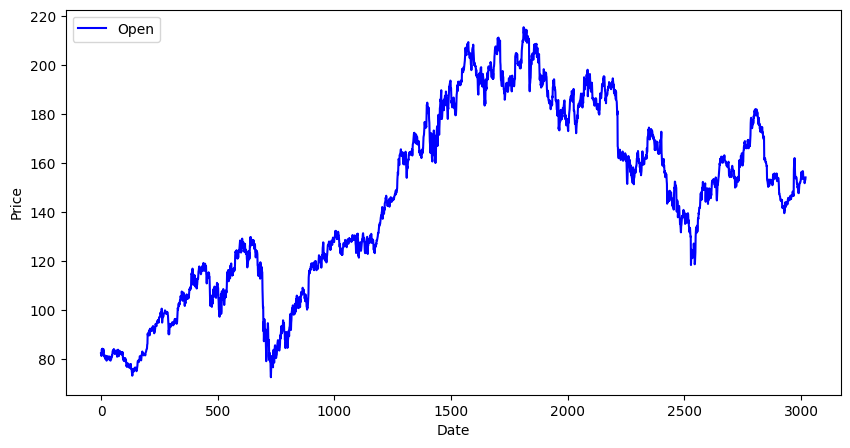

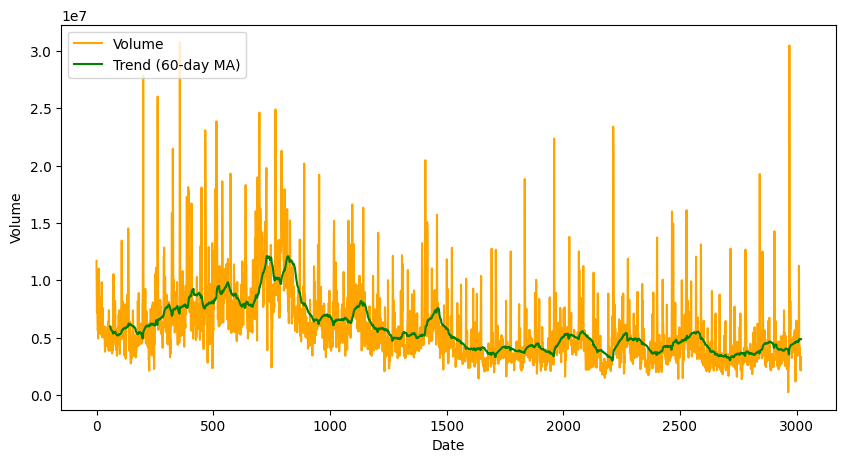

In [5]:
visualization.plot_price_and_volume(indexes, series, df['Volume'][series.index])

Autocorrelation analysis

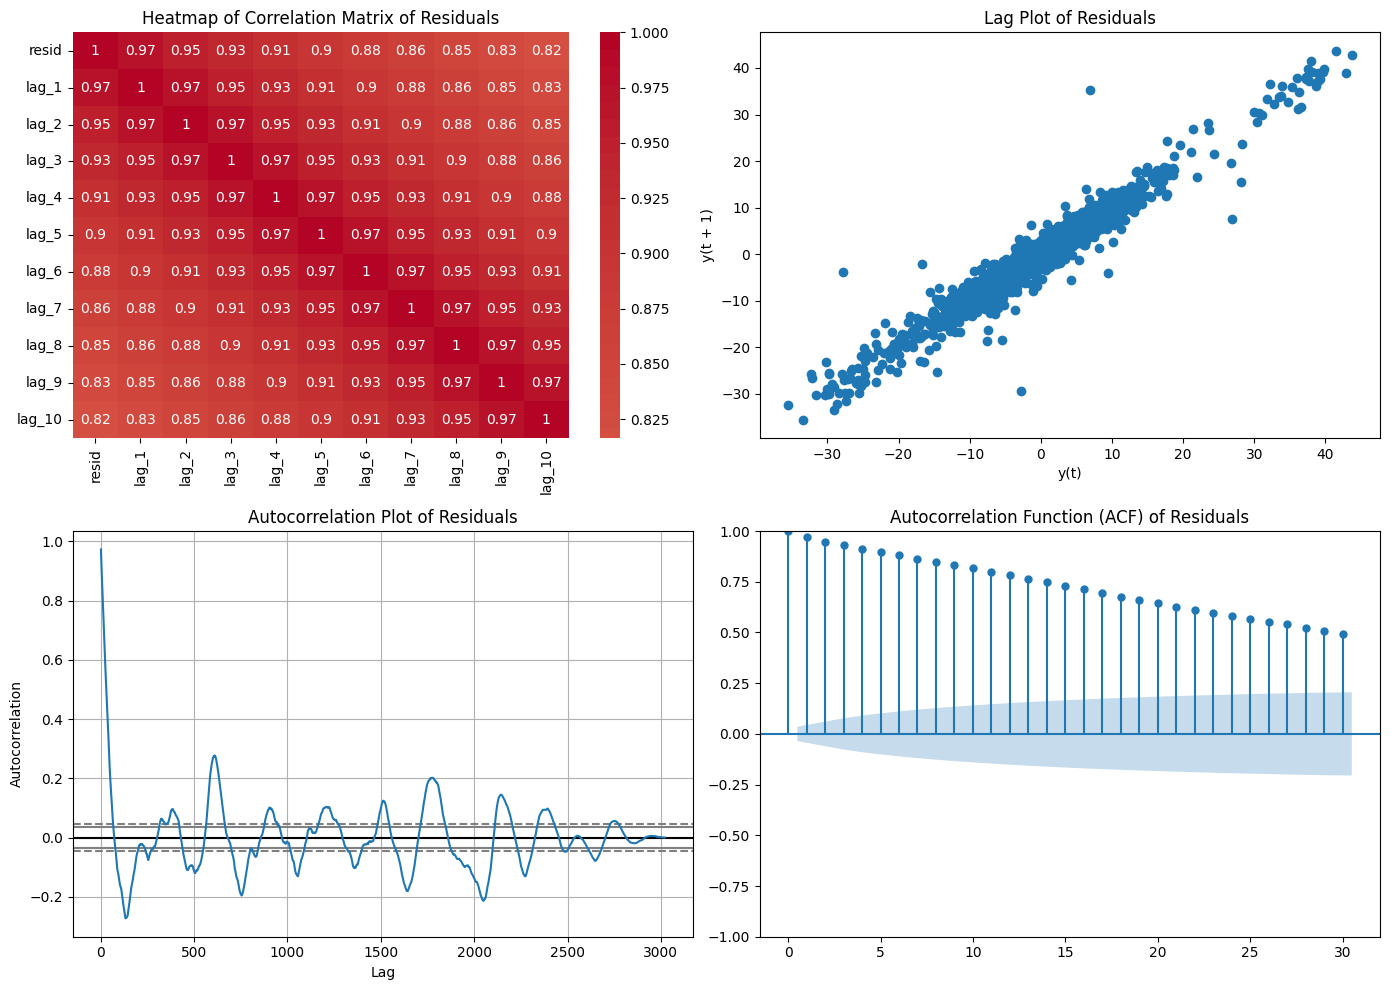

In [6]:
visualization.plot_autocorrelation_analysis(resid, 'resid', 'Residuals')

Analyze returns

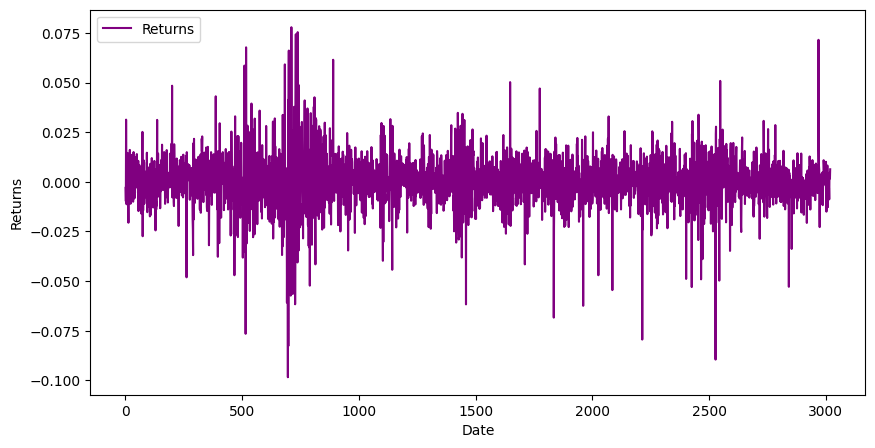

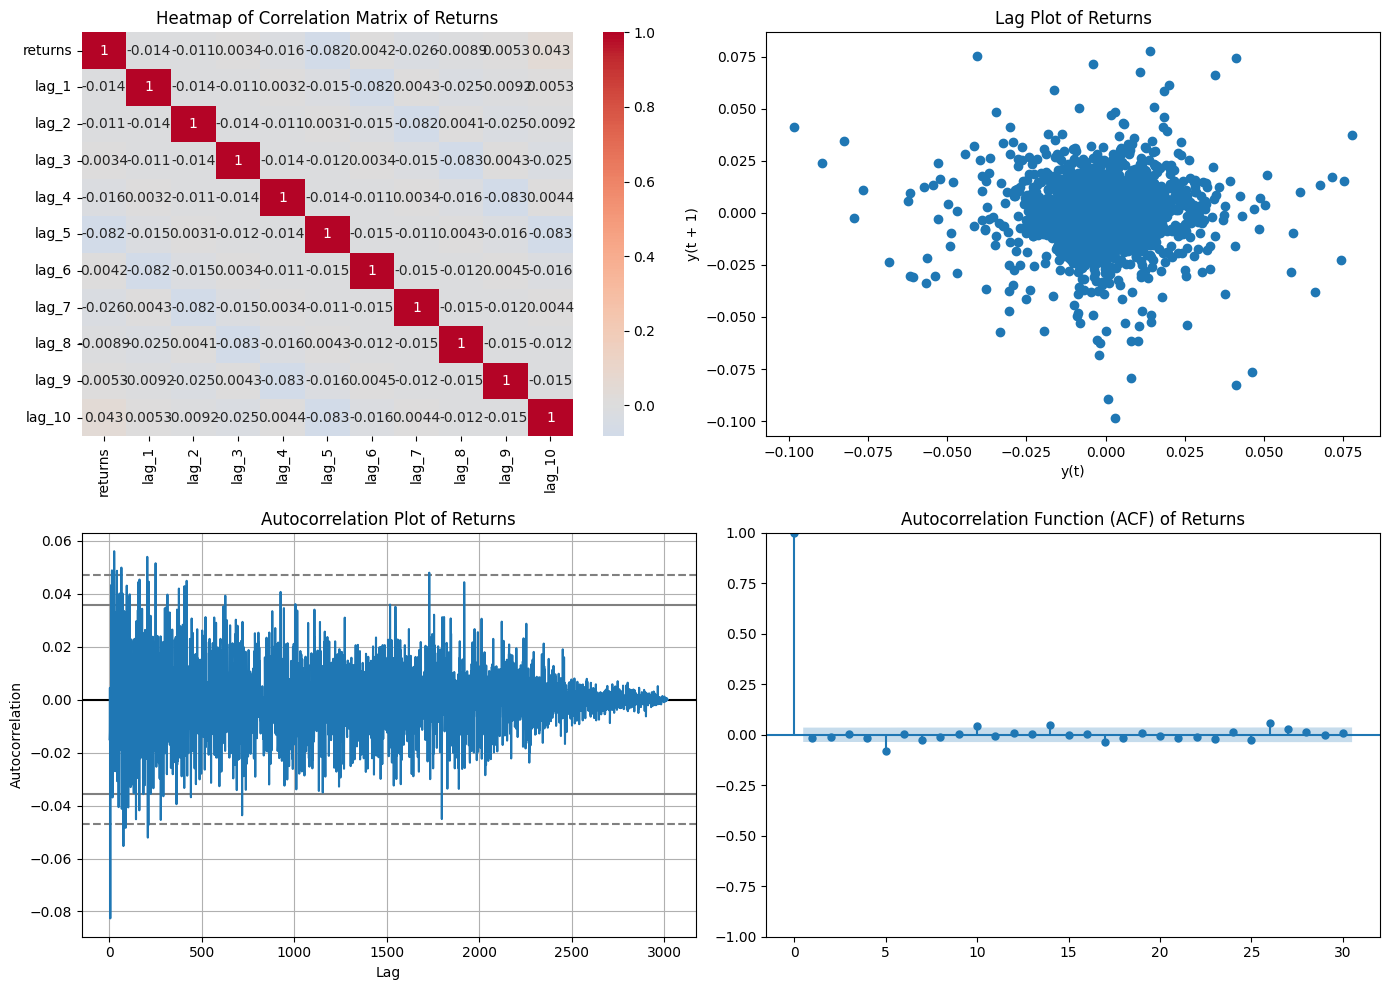

In [7]:
returns = data_preprocessing.compute_returns(series)
visualization.plot_returns(indexes[1:], returns)

visualization.plot_autocorrelation_analysis(returns, 'returns', 'Returns')

## ARIMA Model

Forecasting of the prices

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=9740.501, Time=1.22 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=9745.277, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=9742.056, Time=0.24 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=9742.584, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=9743.952, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=9742.173, Time=0.47 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=9740.101, Time=1.65 sec
 ARIMA(1,1,1)(1,0,0)[7] intercept   : AIC=9740.239, Time=0.99 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : AIC=9741.194, Time=2.82 sec
 ARIMA(1,1,1)(1,0,2)[7] intercept   : AIC=9741.092, Time=3.29 sec
 ARIMA(1,1,1)(0,0,2)[7] intercept   : AIC=9739.573, Time=1.97 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=9740.413, Time=0.53 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=9740.404, Time=0.46 sec
 ARIMA(2,1,1)(0,0,2)[7] intercept   : AIC=9744.045, Time=0.99 sec
 ARIMA(1,1,2)(0,0,2)[7] intercept

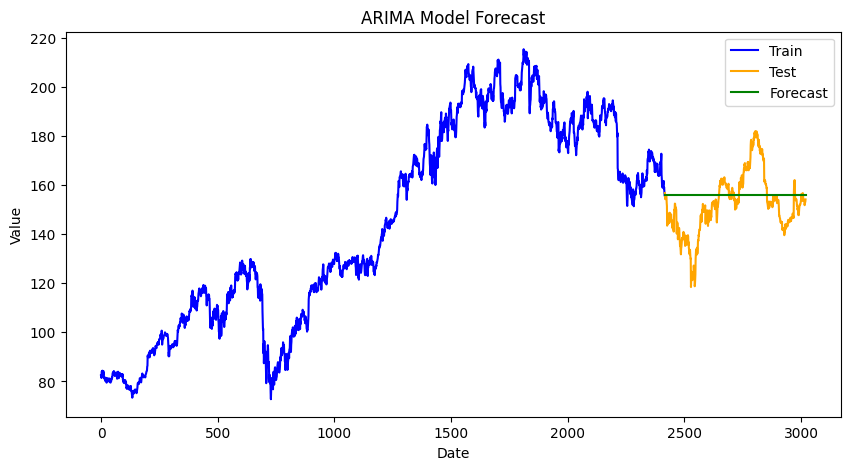

In [8]:
train, test = data_preprocessing.split_series(series)

forecast, model_fit, best_order = arima_forecasting.fit_arima_forecast(train, test)

visualization.plot_arima_forecast(train, test, forecast)

Forecasting of the STL residuals

Best Order for Residuals: (1, 0, 1)
Best Order for Trend: (2, 1, 3)
RMSE (Hybrid): 15.158222197143004
MAE (Hybrid): 11.288690341369321
R2 Score (Hybrid): -0.5100685844337602


c:\Users\eknut\Documents\Koodit\Projektit\stock-market-forecasting\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


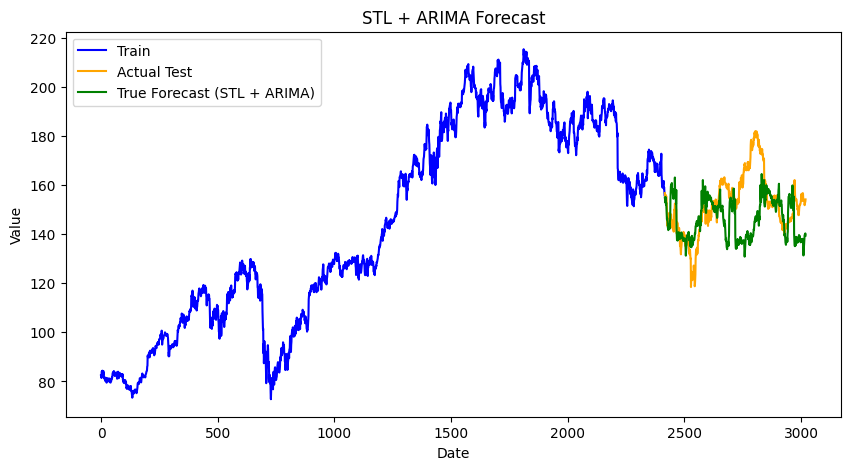

In [9]:
train, test = data_preprocessing.split_series(series)

train_series, test_series = data_preprocessing.split_series(series)

total_forecast, trend_forecast, seasonal_forecast, resid_forecast, best_order_resid, best_order_trend = arima_forecasting.fit_stl_arima_forecast(train_series, test_series)

visualization.plot_stl_arima_forecast(train_series, test_series, total_forecast)

## RNN and LSTM Models

In [10]:
y = df["Open"]

# Ensure indices are sorted
df = df.sort_values('Date').reset_index(drop=True)

df = data_preprocessing.compute_technical_indicators(df)

df = data_preprocessing.add_cyclical_date_features(df)

# Drop unnecessary columns
X = df.drop(columns=["Date", "Open", "Name", "DayOfWeek", "Month"])
n_features = X.shape[1]
non_cyclical_idx = [i for i, col in enumerate(X.columns) if col in ['High', 'Low', 'Close', 'Volume', 'Year']]
print(X.head())

# Create sequences
n_past = 63 # Use past 63 days (approx. 3 months of trading days)
n_future_5 = 5 # Predict next trading week
n_future_21 = 21 # Predict next trading month

X_train_5, y_train_5, X_val_5, y_val_5, X_test_5, y_test_5 = data_preprocessing.get_train_val_test(X.values, y, n_past, n_future_5)
X_train_21, y_train_21, X_val_21, y_val_21, X_test_21, y_test_21 = data_preprocessing.get_train_val_test(X.values, y, n_past, n_future_21)

X_train_5, y_train_5, X_val_5, y_val_5, X_test_5, y_test_5, scaler_X_5, scaler_y_5 = data_preprocessing.normalize_datasets(X_train_5, y_train_5, X_val_5, y_val_5, X_test_5, y_test_5, non_cyclical_idx)
X_train_21, y_train_21, X_val_21, y_val_21, X_test_21, y_test_21, scaler_X_21, scaler_y_21 = data_preprocessing.normalize_datasets(X_train_21, y_train_21, X_val_21, y_val_21, X_test_21, y_test_21, non_cyclical_idx)

# Set device
device = training.get_device()
print(f"Using device: {device}")

# Create DataLoaders
batch_size = 64
train_loader_5, val_loader_5, test_loader_5 = data_preprocessing.create_dataloaders(X_train_5, y_train_5, X_val_5, y_val_5, X_test_5, y_test_5, batch_size=batch_size, device=device)
train_loader_21, val_loader_21, test_loader_21 = data_preprocessing.create_dataloaders(X_train_21, y_train_21, X_val_21, y_val_21, X_test_21, y_test_21, batch_size=batch_size, device=device)

     High    Low  Close   Volume     RSI_14  BB_Width    ATR_14   SMA_50  \
49  83.76  82.64  83.38  5370400  68.417285  0.046485  1.134735  81.4796   
50  83.72  82.61  82.87  4299500  63.018564  0.051148  1.132968  81.4958   
51  83.41  82.82  83.30  6414500  65.491082  0.056834  1.094185  81.5228   
52  83.75  82.99  83.58  3870300  67.036558  0.062442  1.070315  81.5444   
53  84.99  83.58  83.81  7404300  68.292717  0.067447  1.094578  81.5216   

    Dist_SMA_50       OBV  Year   Day_Sin   Day_Cos  Month_Sin     Month_Cos  
49     0.023324   5638200  2006  0.974928 -0.222521        1.0  6.123234e-17  
50     0.016862   1338700  2006  0.433884 -0.900969        1.0  6.123234e-17  
51     0.021800   7753200  2006 -0.433884 -0.900969        1.0  6.123234e-17  
52     0.024963  11623500  2006  0.000000  1.000000        1.0  6.123234e-17  
53     0.028071  19027800  2006  0.781831  0.623490        1.0  6.123234e-17  
Using device: cpu


### Functions

### RNN 

In [16]:
model_5 = model_definitions.RNNModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_5)
model_21 = model_definitions.RNNModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_21)

num_epochs = 100
criterion = nn.SmoothL1Loss()
optimizer_5 = torch.optim.Adam(model_5.parameters(), lr=1e-4)
optimizer_21 = torch.optim.Adam(model_21.parameters(), lr=1e-4)
scheduler_5 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_5, mode='min', factor=0.5, patience=10)
scheduler_21 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_21, mode='min', factor=0.5, patience=10)

train = False

model_5, model_21 = None, None

# Train models
if train:
    print("Training 5-day RNN model...")
    model_5 = training.train_model(model_5, train_loader_5, val_loader_5, optimizer_5, criterion, scheduler_5, num_epochs, type='RNN 5-day', device=device)
    print("Training 21-day RNN model...")
    model_21 = training.train_model(model_21, train_loader_21, val_loader_21, optimizer_21, criterion, scheduler_21, num_epochs, type='RNN 21-day', device=device)
else:
    print("Loading pre-trained models...")
    model_5 = model_definitions.RNNModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_5)
    model_21 = model_definitions.RNNModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_21)
    model_5.load_state_dict(torch.load('models/best_model_RNN 5-day.pth', map_location=device))
    model_21.load_state_dict(torch.load('models/best_model_RNN 21-day.pth', map_location=device))
    model_5.to(device)
    model_21.to(device)

Loading pre-trained models...


C:\Users\eknut\AppData\Local\Temp\ipykernel_9848\3387513586.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_5.load_state_dict(torch.load('models/best_model_RNN 5-

Evaluating 5-day RNN model...
Test RMSE: 4.8956
Test MAE: 4.8956
Evaluating 21-day RNN model...
Test RMSE: 3.8653
Test MAE: 3.8653


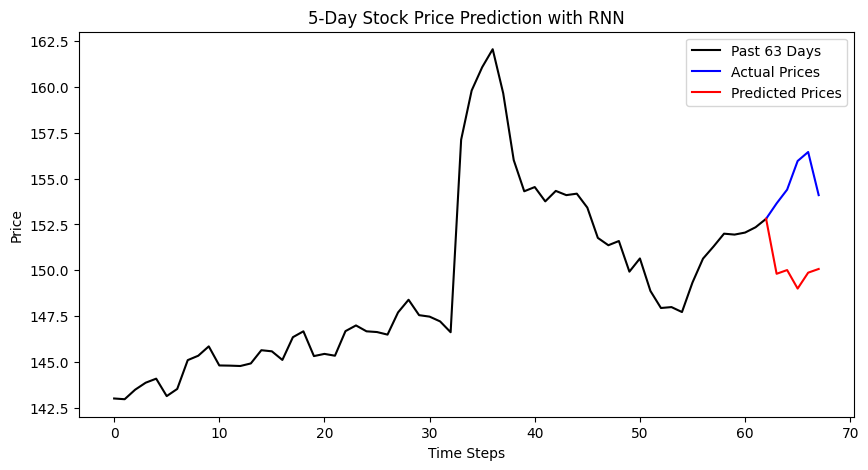

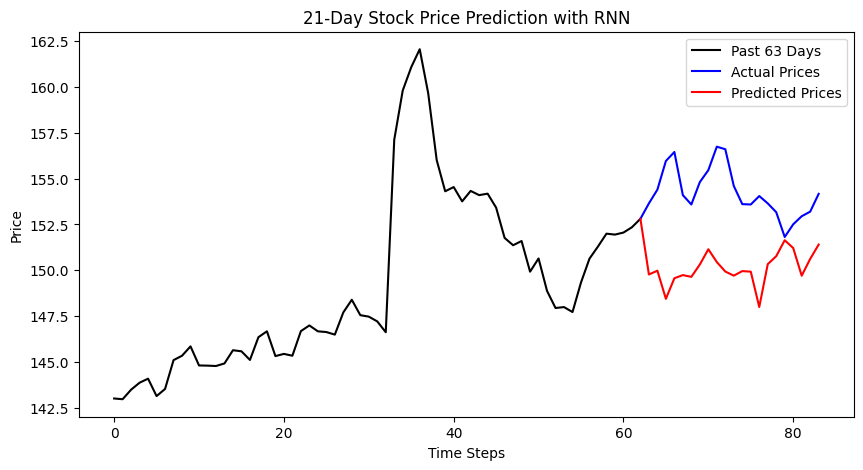

In [17]:
# Evaluate models
print("Evaluating 5-day RNN model...")
simulated_prediction_5, y_test_5_real = training.evaluate_model(model_5, test_loader_5, scaler_y_5, device=device)
print("Evaluating 21-day RNN model...")
simulated_prediction_21, y_test_21_real = training.evaluate_model(model_21, test_loader_21, scaler_y_21, device=device)

past_data_5, true_future_5 = data_preprocessing.get_recent_prediction_window(y, n_future_5)
visualization.plot_prediction(past_data_5, true_future_5, simulated_prediction_5, 'RNN', '5-Day')

past_data_21, true_future_21 = data_preprocessing.get_recent_prediction_window(y, n_future_21)
visualization.plot_prediction(past_data_21, true_future_21, simulated_prediction_21, 'RNN', '21-Day')

### LSTM Model

In [18]:
model_lstm_5 = model_definitions.LSTMModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_5)
model_lstm_21 = model_definitions.LSTMModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_21)

num_epochs = 100
criterion = nn.SmoothL1Loss()
optimizer_lstm_5 = torch.optim.Adam(model_lstm_5.parameters(), lr=1e-4)
optimizer_lstm_21 = torch.optim.Adam(model_lstm_21.parameters(), lr=1e-4)
scheduler_lstm_5 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_lstm_5, mode='min', factor=0.5, patience=10)
scheduler_lstm_21 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_lstm_21, mode='min', factor=0.5, patience=10)

train = False

model_lstm_5, model_lstm_21 = None, None

# Train models
if train:
    print("Training 5-day LSTM model...")
    model_lstm_5 = training.train_model(model_lstm_5, train_loader_5, val_loader_5, optimizer_lstm_5, criterion, scheduler_lstm_5, num_epochs, type='LSTM 5-day', device=device)
    print("Training 21-day LSTM model...")
    model_lstm_21 = training.train_model(model_lstm_21, train_loader_21, val_loader_21, optimizer_lstm_21, criterion, scheduler_lstm_21, num_epochs, type='LSTM 21-day', device=device)
else:
    print("Loading pre-trained LSTM models...")
    model_lstm_5 = model_definitions.LSTMModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_5)
    model_lstm_21 = model_definitions.LSTMModel(input_size=n_features, hidden_size=128, num_layers=2, output_size=n_future_21)
    model_lstm_5.load_state_dict(torch.load('models/best_model_LSTM 5-day.pth', map_location=device))
    model_lstm_21.load_state_dict(torch.load('models/best_model_LSTM 21-day.pth', map_location=device))
    model_lstm_5.to(device)
    model_lstm_21.to(device)

Loading pre-trained LSTM models...


C:\Users\eknut\AppData\Local\Temp\ipykernel_9848\3901074792.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_lstm_5.load_state_dict(torch.load('models/best_model_L

Evaluating 5-day LSTM model...
Test RMSE: 5.8640
Test MAE: 5.8640
Evaluating 21-day LSTM model...
Test RMSE: 5.8791
Test MAE: 5.8791


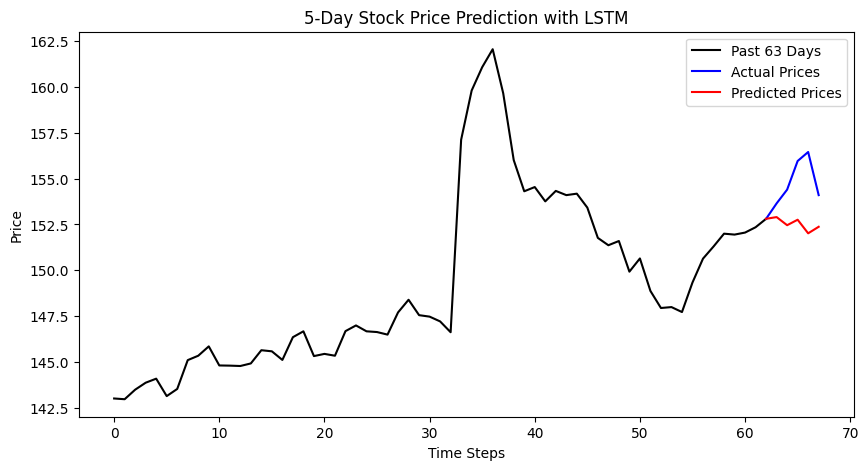

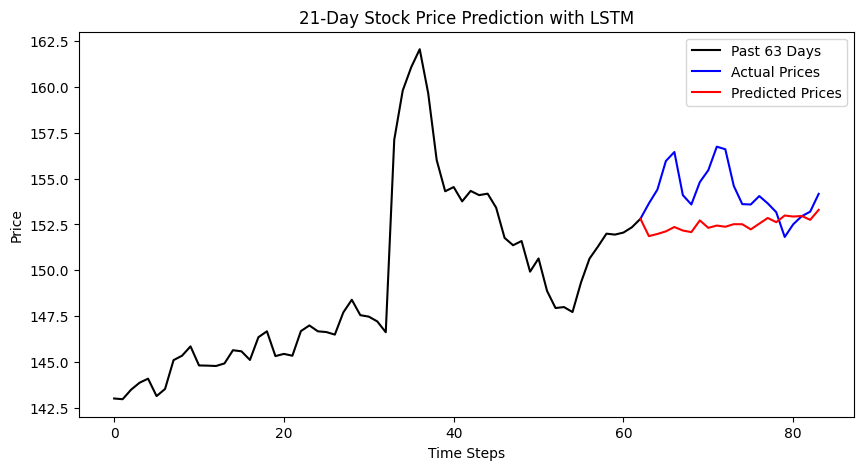

In [19]:
# Evaluate models
print("Evaluating 5-day LSTM model...")
simulated_prediction_lstm_5, y_test_lstm_5_real = training.evaluate_model(model_lstm_5, test_loader_5, scaler_y_5, device=device)
print("Evaluating 21-day LSTM model...")
simulated_prediction_lstm_21, y_test_lstm_21_real = training.evaluate_model(model_lstm_21, test_loader_21, scaler_y_21, device=device)

past_data_5, true_future_5 = data_preprocessing.get_recent_prediction_window(y, n_future_5)
visualization.plot_prediction(past_data_5, true_future_5, simulated_prediction_lstm_5, 'LSTM', '5-Day')

past_data_21, true_future_21 = data_preprocessing.get_recent_prediction_window(y, n_future_21)
visualization.plot_prediction(past_data_21, true_future_21, simulated_prediction_lstm_21, 'LSTM', '21-Day')

# Transformer

Defining the model arhitecture

In [20]:
model_transformer_5 = model_definitions.TransformerModel(input_size=n_features, d_model=128, nhead=8, num_layers=2, dim_feedforward=512, output_size=n_future_5)
model_transformer_21 = model_definitions.TransformerModel(input_size=n_features, d_model=128, nhead=8, num_layers=2, dim_feedforward=512, output_size=n_future_21)

num_epochs = 100
criterion = nn.SmoothL1Loss()
optimizer_transformer_5 = torch.optim.Adam(model_transformer_5.parameters(), lr=1e-4)
optimizer_transformer_21 = torch.optim.Adam(model_transformer_21.parameters(), lr=1e-4)
scheduler_transformer_5 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_transformer_5, mode='min', factor=0.5, patience=10)
scheduler_transformer_21 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_transformer_21, mode='min', factor=0.5, patience=10)

c:\Users\eknut\Documents\Koodit\Projektit\stock-market-forecasting\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Normalizing all of the self-defined features correctly and initializing data loaders for transformer

In [21]:
all_features = X.columns.tolist()
cyclical_features = ['Day_Sin', 'Day_Cos', 'Month_Sin', 'Month_Cos']
non_cyclical_features = [col for col in all_features if col not in cyclical_features]
non_cyclical_idx_corrected = [i for i, col in enumerate(all_features) if col in non_cyclical_features]

X_train_5_raw, y_train_5_raw, X_val_5_raw, y_val_5_raw, X_test_5_raw, y_test_5_raw = data_preprocessing.get_train_val_test(X.values, y.values, n_past, n_future_5)


X_train_5_corrected, X_val_5_corrected, X_test_5_corrected, y_train_5_corrected, y_val_5_corrected, y_test_5_corrected, y_scaler_5_corrected = data_preprocessing.normalize_data_correctly(
    X_train_5_raw, X_val_5_raw, X_test_5_raw, 
    y_train_5_raw, y_val_5_raw, y_test_5_raw, 
    non_cyclical_idx_corrected
)

train_loader_5_corrected, val_loader_5_corrected, test_loader_5_corrected = data_preprocessing.create_dataloaders(X_train_5_corrected, y_train_5_corrected, X_val_5_corrected, y_val_5_corrected, X_test_5_corrected, y_test_5_corrected, batch_size=batch_size)

In [22]:
X_train_21_raw, y_train_21_raw, X_val_21_raw, y_val_21_raw, X_test_21_raw, y_test_21_raw = data_preprocessing.get_train_val_test(X.values, y.values, n_past, n_future_21)

X_train_21_corrected, X_val_21_corrected, X_test_21_corrected, y_train_21_corrected, y_val_21_corrected, y_test_21_corrected, y_scaler_21_corrected = data_preprocessing.normalize_data_correctly(
    X_train_21_raw, X_val_21_raw, X_test_21_raw, 
    y_train_21_raw, y_val_21_raw, y_test_21_raw, 
    non_cyclical_idx_corrected
)

train_loader_21_corrected, val_loader_21_corrected, test_loader_21_corrected = data_preprocessing.create_dataloaders(X_train_21_corrected, y_train_21_corrected, X_val_21_corrected, y_val_21_corrected, X_test_21_corrected, y_test_21_corrected, batch_size=batch_size)

In [24]:
model_transformer_5_fixed = model_definitions.TransformerModel(
    input_size=n_features, 
    d_model=128, 
    nhead=8, 
    num_layers=2, 
    dim_feedforward=512, 
    output_size=n_future_5
)

train = False

if train:
    num_epochs = 100
    criterion = nn.SmoothL1Loss()
    optimizer_transformer_5_fixed = torch.optim.Adam(model_transformer_5_fixed.parameters(), lr=1e-4)
    scheduler_transformer_5_fixed = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_transformer_5_fixed, mode='min', factor=0.5, patience=10)

    model_transformer_5_fixed = training.train_model(
        model_transformer_5_fixed, 
        train_loader_5_corrected, 
        val_loader_5_corrected, 
        optimizer_transformer_5_fixed, 
        criterion, 
        scheduler_transformer_5_fixed, 
        num_epochs, 
        'Transformer_5_day',
        device=device
    )
else:
    print("Loading pre-trained Transformer 5-day model...")
    model_transformer_5_fixed = model_definitions.TransformerModel(
        input_size=n_features, 
        d_model=128, 
        nhead=8, 
        num_layers=2, 
        dim_feedforward=512, 
        output_size=n_future_5
    )
    model_transformer_5_fixed.load_state_dict(torch.load('models/best_model_Transformer_5_day.pth', map_location=device))

Loading pre-trained Transformer 5-day model...


C:\Users\eknut\AppData\Local\Temp\ipykernel_9848\3048184103.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_transformer_5_fixed.load_state_dict(torch.load('models

In [25]:
model_transformer_21_fixed = model_definitions.TransformerModel(
    input_size=n_features, 
    d_model=128, 
    nhead=8, 
    num_layers=2, 
    dim_feedforward=512, 
    output_size=n_future_21
)

train = False

if train:
    optimizer_transformer_21_fixed = torch.optim.Adam(model_transformer_21_fixed.parameters(), lr=1e-4)
    scheduler_transformer_21_fixed = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_transformer_21_fixed, mode='min', factor=0.5, patience=10)

    model_transformer_21_fixed = training.train_model(
        model_transformer_21_fixed, 
        train_loader_21_corrected, 
        val_loader_21_corrected, 
        optimizer_transformer_21_fixed, 
        criterion, 
        scheduler_transformer_21_fixed, 
        num_epochs, 
        'Transformer_21_day',
        device=device
    )
else:
    print("Loading pre-trained Transformer 21-day model...")
    model_transformer_21_fixed = model_definitions.TransformerModel(
        input_size=n_features, 
        d_model=128, 
        nhead=8, 
        num_layers=2, 
        dim_feedforward=512, 
        output_size=n_future_21
    )
    model_transformer_21_fixed.load_state_dict(torch.load('models/best_model_Transformer_21_day.pth', map_location=device))

Loading pre-trained Transformer 21-day model...


C:\Users\eknut\AppData\Local\Temp\ipykernel_9848\608897347.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_transformer_21_fixed.load_state_dict(torch.load('models

Evaluating 5-day Transformer model...
Test RMSE: 5.4061
Test MAE: 5.4061
Evaluating 21-day Transformer model...
Test RMSE: 3.9987
Test MAE: 3.9987


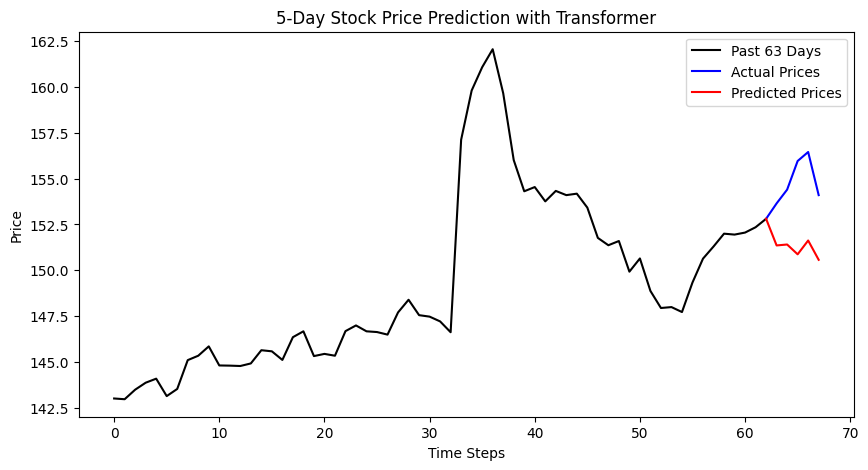

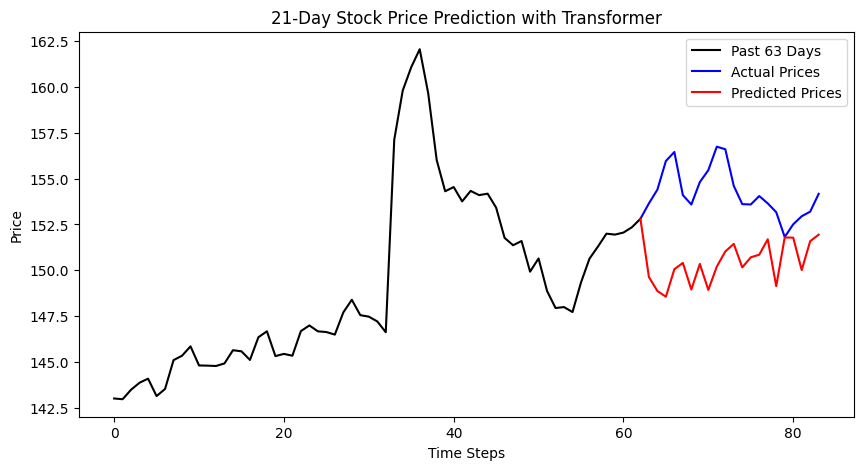

In [26]:
# Evaluate models
print("Evaluating 5-day Transformer model...")
simulated_prediction_transformer_5_fixed, y_test_transformer_5_fixed_real = training.evaluate_model(model_transformer_5_fixed, test_loader_5_corrected, y_scaler_5_corrected, device=device)
print("Evaluating 21-day Transformer model...")
simulated_prediction_transformer_21_fixed, y_test_transformer_21_fixed_real = training.evaluate_model(model_transformer_21_fixed, test_loader_21_corrected, y_scaler_21_corrected, device=device)

past_data_5, true_future_5 = data_preprocessing.get_recent_prediction_window(y, n_future_5)
visualization.plot_prediction(past_data_5, true_future_5, simulated_prediction_transformer_5_fixed, 'Transformer', '5-Day')

past_data_21, true_future_21 = data_preprocessing.get_recent_prediction_window(y, n_future_21)
visualization.plot_prediction(past_data_21, true_future_21, simulated_prediction_transformer_21_fixed, 'Transformer', '21-Day')